# Conceptual and Analytic Thesis Figures

Generates the three schematic/analytic figures, in the order they appear in the thesis:

1. **Figure 1.1** `fracture_diagrams.png`: fracture-interaction schematic (after Taleghani & Olson, 2014).
2. **Figure 1.2** `frac_hit_signature.png`: the expected cross-well DSS fracture-hit signature (the "heart"),
   from the plane-strain Westergaard solution with a KGD tip trajectory and gauge-length averaged strain.
3. **Figure 2.1** `workflow_diagram.png`: the thesis modeling workflow.

None of these need simulation data; everything is analytic or drawn. Figures are saved to `../figures/`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
SAVEDIR = "../figures/"   # created on demand (relative to notebooks/)
os.makedirs(SAVEDIR, exist_ok=True)

## Fracture-interaction schematic (Figure 1.1)

Programmatic recreation of the hand-drawn fracture-interaction diagram (after
Taleghani & Olson, 2014): schematic cross sections of a hydraulic fracture (blue)
launched from a vertical well (gray) through horizontal stratigraphy (brown
interfaces), meeting a pre-existing fracture (black dashed):

- **A - crossing:** the induced fracture crosses the pre-existing fracture and ends.
- **B - deflection:** the induced fracture is diverted and travels along the pre-existing fracture.
- **C - double deflection:** diverted by the pre-existing fracture, then diverted again along a bedding interface.

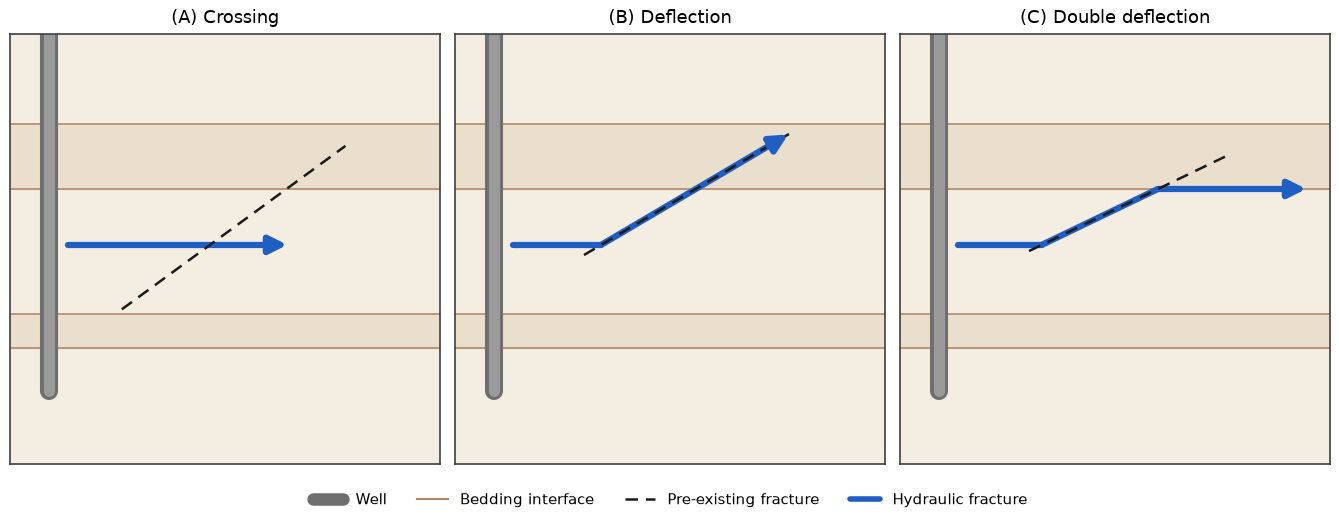

In [3]:
def draw_interaction_panel(ax, mode, title):
    """Draw one fracture-interaction cross section (after Taleghani & Olson, 2014).

    mode: "cross"   - induced fracture crosses the pre-existing fracture
          "deflect" - induced fracture diverts along the pre-existing fracture
          "double"  - diverted by the pre-existing fracture, then by a bedding
                      interface (double deflection)
    """
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_linewidth(1.2)
        s.set_color("0.25")
    ax.set_title(title, fontsize=13, pad=8)

    # --- stratigraphy: alternating soft bands separated by thin interface lines
    iface = 6.4                                   # the interface followed in panel C
    horizons = [2.7, 3.5, iface, 7.9]
    bands = [0.0] + horizons + [10.0]
    shades = ["#f4ede1", "#e9dfcc", "#f4ede1", "#e9dfcc", "#f4ede1"]
    for y_lo, y_hi, fc in zip(bands[:-1], bands[1:], shades):
        ax.axhspan(y_lo, y_hi, color=fc, zorder=0)
    for yl in horizons:
        ax.plot([0, 10], [yl, yl], color="#b08968", lw=1.2, zorder=1)

    # --- vertical well: cased hole with rounded shoe
    ax.plot([0.9, 0.9], [10.0, 1.7], color="#6e6e6e", lw=13,
            solid_capstyle="round", zorder=2)
    ax.plot([0.9, 0.9], [10.0, 1.7], color="#9a9a9a", lw=8,
            solid_capstyle="round", zorder=2)

    y0 = 5.1                                          # injection depth
    HF = dict(color="#1f5fc4", lw=4.5, solid_capstyle="round", zorder=4)  # induced
    NF = dict(color="0.1", lw=1.8, ls=(0, (5, 3.2)), zorder=5)            # pre-existing

    def tip_arrow(x0, y0_, x1, y1):
        # growth-direction arrowhead at the induced-fracture tip
        ax.annotate("", xy=(x1, y1), xytext=(x0, y0_), zorder=6,
                    arrowprops=dict(arrowstyle="-|>", color="#1f5fc4",
                                    lw=4.5, mutation_scale=26,
                                    shrinkA=0, shrinkB=0))

    if mode == "cross":
        # induced fracture runs straight and crosses the pre-existing fracture
        ax.plot([1.35, 5.9], [y0, y0], **HF)
        tip_arrow(5.9, y0, 6.45, y0)
        ax.plot([2.6, 7.8], [3.6, 7.4], **NF)
    elif mode == "deflect":
        # induced fracture turns into the pre-existing plane and follows it;
        # the dashed trace is collinear with the blue diagonal
        xk = 3.4
        m = (7.55 - y0) / (7.55 - xk)
        ax.plot([1.35, xk], [y0, y0], **HF)
        ax.plot([xk, 7.3], [y0, y0 + m*(7.3 - xk)], **HF)
        tip_arrow(7.3, y0 + m*(7.3 - xk), 7.75, y0 + m*(7.75 - xk))
        ax.plot([3.0, 7.9], [y0 + m*(3.0 - xk), y0 + m*(7.9 - xk)], **NF)
    else:  # "double"
        # diverted along the pre-existing plane up to the bedding interface,
        # then diverted again along the interface; the pre-existing fracture
        # continues (dashed) past the interface
        xk, xi = 3.3, 6.0
        m = (iface - y0) / (xi - xk)
        ax.plot([1.35, xk], [y0, y0], **HF)
        ax.plot([xk, xi], [y0, iface], **HF)
        ax.plot([xi, 8.9], [iface, iface], **HF)
        tip_arrow(8.9, iface, 9.45, iface)
        ax.plot([3.0, 7.7], [y0 + m*(3.0 - xk), y0 + m*(7.7 - xk)], **NF)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 5.0))
for ax, mode, title in zip(axes, ("cross", "deflect", "double"),
                           ("(A) Crossing", "(B) Deflection", "(C) Double deflection")):
    draw_interaction_panel(ax, mode, title)

# shared legend below the panels (proxy artists)
from matplotlib.lines import Line2D
handles = [
    Line2D([], [], color="#6e6e6e", lw=9, solid_capstyle="round", label="Well"),
    Line2D([], [], color="#b08968", lw=1.5, label="Bedding interface"),
    Line2D([], [], color="0.1", lw=1.8, ls=(0, (5, 3.2)), label="Pre-existing fracture"),
    Line2D([], [], color="#1f5fc4", lw=4, solid_capstyle="round", label="Hydraulic fracture"),
]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False,
           fontsize=11, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.savefig(SAVEDIR + "fracture_diagrams.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()


## Expected fracture-hit strain signature (Figure 1.2)

The fracture is a plane-strain, uniformly pressurized (mode-I) crack (Westergaard closed form),
growing from the origin with the toughness-dominated KGD length evolution $L(t) \propto t^{2/3}$.
The fiber is a line of channels at a fixed standoff; each channel reports the displacement
difference over the gauge length, the same relation a DAS/DSS interrogator applies, so the gauge
straddling the crack records the opening jump. Parameters mirror the two-dimensional
single-fracture GEOS case in Chapter 2 ($E = 30$ GPa, $\nu = 0.25$, standoff 19 m, gauge 2 m).

## Parameters
Values mirror the two-dimensional single-fracture simulation setup in Chapter 2.

In [4]:
E, nu = 30e9, 0.25            # Young's modulus [Pa], Poisson's ratio
mu = E / (2*(1+nu))           # shear modulus [Pa]
p_net = 1.5e6                 # net pressure in the fracture [Pa]
L_max, T = 21.0, 100.0        # maximum fracture length [m], total injection time [s]
xi_f = 19.0                   # fiber standoff along the propagation axis [m]
Lg = 2.0                      # gauge length [m]
eta = np.arange(-100, 100.5, 1.0)   # fiber channel positions [m]
t = np.arange(1, T+0.5, 0.5)        # time samples [s]

## Westergaard displacement field
For a crack of half-length $a$ centered at $c$ on the propagation axis, with complex coordinate
$z = (\xi - c) + i\eta$, the opening-direction displacement under plane strain is
$2\mu u = 2(1-\nu)\,\mathrm{Im}\,\bar{Z} - \eta\,\mathrm{Re}\,Z$, with
$\bar{Z} = p(\sqrt{z^2-a^2} - z)$ and $Z = p(z/\sqrt{z^2-a^2} - 1)$.
The square root is evaluated branch-safely as $\sqrt{z-a}\sqrt{z+a}$ so that the opening
discontinuity across the crack faces is captured.

In [5]:
def sqrt_branch(z, a):
    return np.sqrt(z - a) * np.sqrt(z + a)

def u_open(xi, eta_pts, c, a):
    """Opening-direction displacement at fixed xi along fiber channel positions eta_pts.
    The crack occupies [c-a, c+a] on the eta=0 plane."""
    z = (xi - c) + 1j*eta_pts
    R = sqrt_branch(z, a)
    intZ = p_net * (R - z)          # Westergaard potential integral
    Z = p_net * (z/R - 1.0)         # Westergaard function
    return (2*(1-nu)*np.imag(intZ) - eta_pts*np.real(Z)) / (2*mu)

## Fracture growth and gauge-averaged strain
The fracture grows one-sidedly from the origin, so the equivalent symmetric crack has center
$c = L/2$ and half-length $a = L/2$. At each time step the axial strain per channel is the
gauge-length displacement difference.

In [6]:
L_t = L_max * (t/T)**(2.0/3.0)   # toughness-dominated KGD growth

wf = np.zeros((len(t), len(eta)))
for i, L in enumerate(L_t):
    c, a = L/2.0, L/2.0
    up = u_open(xi_f, eta + Lg/2, c, a)
    um = u_open(xi_f, eta - Lg/2, c, a)
    wf[i] = (up - um) / Lg           # gauge-averaged axial strain

t_hit = t[np.argmax(L_t >= xi_f)]
print(f"Fracture tip reaches the fiber at t = {t_hit:.1f} s")

Fracture tip reaches the fiber at t = 86.5 s


## Waterfall plot
Waterfall of the gauge-averaged axial strain with position along the fiber on the vertical axis and time on the horizontal axis (red = extension, blue = compression), zoomed to $\pm50$ m around the hit location.
The color scale saturates at the 99.5th percentile so the pre-hit heart-shaped extension zone
remains visible next to the high-amplitude fracture-hit core.

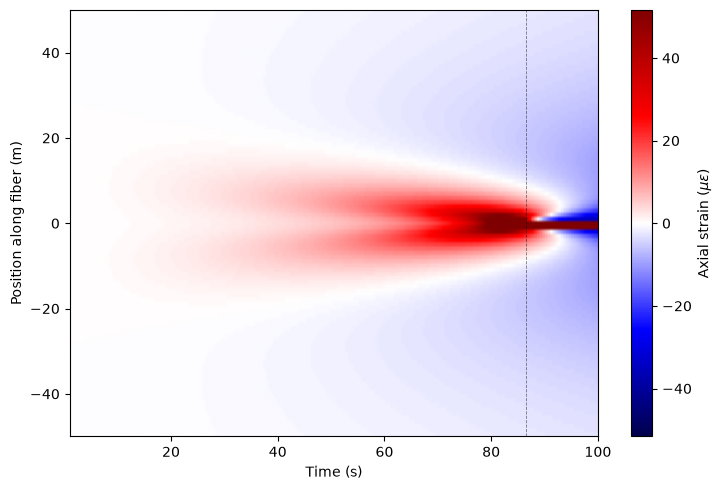

In [7]:
wf_ue = wf * 1e6   # microstrain
mask = np.abs(eta) <= 50           # zoom to +/- 50 m around the hit location
lim = np.percentile(np.abs(wf_ue[:, mask]), 99.5)

fig, ax = plt.subplots(figsize=(7.5, 5))
im = ax.imshow(wf_ue[:, mask].T, aspect="auto", cmap="seismic", vmin=-lim, vmax=lim,
               extent=[t[0], t[-1], -50, 50], origin="lower")
ax.axvline(t_hit, color="k", lw=0.6, ls="--", alpha=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Position along fiber (m)")
cb = fig.colorbar(im, ax=ax, label=r"Axial strain ($\mu\varepsilon$)")
fig.tight_layout()
fig.savefig( SAVEDIR + "frac_hit_signature.png", dpi=300, bbox_inches="tight")
plt.show()

The waterfall reproduces the expected cross-well signature: a widening zone of
extension centered on the eventual hit location as the fracture approaches (the heart shape),
followed by a localized, high-amplitude extension at the fracture hit flanked by compressional
lobes once the tip crosses the fiber (dashed line). The saved figure `frac_hit_signature.png`
is used in the thesis introduction.

## Modeling workflow diagram (Figure 2.1)

Five-stage workflow of the thesis (field characterization to waterfall comparison) with the
scenario-refinement feedback loop drawn beneath the main row.

In [ ]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# titles-only workflow in a 3-over-2 grid: 1-2-3 across the top, the flow
# wraps down to 4 and back to 5 (under 2), so the refinement loop points
# straight up into block 2
titles = {
    1: "1. Field\ncharacterization",
    2: "2. Reservoir model\nconstruction",
    3: "3. Hydraulic fracturing\nsimulation",
    4: "4. Virtual-fiber\nDSS extraction",
    5: "5. Waterfall-plot analysis\nand comparison",
}
bw, bh = 2.2, 0.95
y_top, y_bot = 2.35, 0.55
pos = {1: (0.55, y_top), 2: (3.45, y_top), 3: (6.35, y_top),
       4: (6.35, y_bot), 5: (3.45, y_bot)}
face, edge, accent = '#d9eaf2', '#2f4b57', '#b0592f'

fig, ax = plt.subplots(figsize=(9.2, 3.7))
ax.set_xlim(0, 9.2); ax.set_ylim(0, 3.7); ax.axis('off')

for k, (x, y) in pos.items():
    ax.add_patch(FancyBboxPatch((x, y), bw, bh,
                                boxstyle="round,pad=0.06,rounding_size=0.12",
                                fc=face, ec=edge, lw=1.6))
    ax.text(x+bw/2, y+bh/2, titles[k], ha='center', va='center',
            fontsize=11, fontweight='bold', color=edge)

def arrow(p, q, **kw):
    ax.add_patch(FancyArrowPatch(p, q, arrowstyle='-|>', mutation_scale=17,
                                 lw=1.7, color=edge, shrinkA=0, shrinkB=0, **kw))

arrow((pos[1][0]+bw+0.09, y_top+bh/2), (pos[2][0]-0.11, y_top+bh/2))   # 1 -> 2
arrow((pos[2][0]+bw+0.09, y_top+bh/2), (pos[3][0]-0.11, y_top+bh/2))   # 2 -> 3
arrow((pos[3][0]+bw/2, y_top-0.09), (pos[4][0]+bw/2, y_bot+bh+0.11))   # 3 -> 4
arrow((pos[4][0]-0.09, y_bot+bh/2), (pos[5][0]+bw+0.11, y_bot+bh/2))   # 4 -> 5

# feedback: box 5 straight up into box 2
xc = pos[5][0] + bw/2
ax.add_patch(FancyArrowPatch((xc, y_bot+bh+0.11), (xc, y_top-0.09),
                             arrowstyle='-|>', mutation_scale=14, lw=1.3,
                             color=accent, linestyle=(0, (4, 3)),
                             shrinkA=0, shrinkB=0))
ax.text(xc-0.15, (y_bot+bh+y_top)/2, 'scenario refinement', ha='right',
        va='center', fontsize=9, color=accent, style='italic')

fig.tight_layout()
fig.savefig(SAVEDIR + 'workflow_diagram.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
